# Cyberattack Detection — Analysis Report

**Dataset:** `cybersecurity_intrusion_data.csv` — 9,537 network sessions, 11 features, each labeled as an attack (`attack_detected = 1`) or normal session (`attack_detected = 0`).

**Goal:** Identify which session characteristics are most associated with detected attacks, using data cleaning, correlation analysis, and visualizations (including a correlation heatmap).


## 1. Data Overview

The dataset has 9,537 rows and 11 columns, covering network, login, and session-level attributes for each session.

In [1]:
import pandas as pd

df = pd.read_csv('cybersecurity_intrusion_data.csv')
print(df.shape)
df.head()

(9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## 2. Data Cleaning

**Missing values:** Only `encryption_used` had missing entries (1,966 of 9,537 rows). These were treated as sessions using no encryption and filled with `'None'` rather than dropped, since encryption status is itself a meaningful signal.

**Duplicates:** No duplicate rows were found after excluding the `session_id` column.

In [2]:
df['encryption_used'] = df['encryption_used'].fillna('None')
dupes = df.drop(columns=['session_id']).duplicated().sum()
print('Duplicate rows (excluding session_id):', dupes)
df['encryption_used'].value_counts()

Missing encryption_used values now: 0


encryption_used
AES     4706
DES     2865
None    1966
Name: count, dtype: int64

## 3. Attacked vs. Normal Sessions — Key Averages

Comparing average behavior between attacked and normal sessions shows attacked sessions have noticeably more failed logins (**1.94 vs. 1.18**) and more login attempts (**4.64 vs. 3.54**) on average, along with a slightly higher IP reputation score (0.37 vs. 0.30, where higher usually signals a riskier IP).

In [3]:
result = (
    df.groupby('attack_detected')
    .agg(
        num_sessions=('failed_logins', 'count'),
        avg_failed_logins=('failed_logins', 'mean'),
        avg_login_attempts=('login_attempts', 'mean'),
        avg_session_duration=('session_duration', 'mean'),
        avg_ip_reputation_score=('ip_reputation_score', 'mean'),
        avg_packet_size=('network_packet_size', 'mean'),
        pct_unusual_time_access=('unusual_time_access', 'mean'),
    )
    .round(2)
    .reset_index()
)
result

,attack_detected,num_sessions,avg_failed_logins,avg_login_attempts,avg_session_duration,avg_ip_reputation_score,avg_packet_size,pct_unusual_time_access
0,0,5273,1.18,3.54,763.32,0.30,501.64,0.15
1,1,4264,1.94,4.64,829.13,0.37,498.93,0.15


## 4. Correlation with Attack Detection

After one-hot encoding the categorical columns (`protocol_type`, `encryption_used`, `browser_type`), correlation of every feature with `attack_detected` was computed. **`failed_logins` (r ≈ 0.36)**, **`login_attempts` (r ≈ 0.28)**, and **`ip_reputation_score` (r ≈ 0.21)** stand out as the strongest predictors — all other features correlate weakly (|r| < 0.14).

In [4]:
df_encoded = pd.get_dummies(df, columns=['protocol_type', 'encryption_used', 'browser_type'])
corr = df_encoded.corr()['attack_detected'].drop('attack_detected').sort_values(key=abs, ascending=False)
corr

failed_logins           0.363726
login_attempts          0.277320
ip_reputation_score     0.211540
browser_type_Unknown    0.134630
session_duration        0.041602
browser_type_Chrome    -0.040087
encryption_used_AES    -0.020693
protocol_type_ICMP     -0.016619
encryption_used_None    0.016161
browser_type_Safari    -0.013289
browser_type_Firefox   -0.010556
unusual_time_access     0.008652
encryption_used_DES     0.008306
browser_type_Edge      -0.008057
protocol_type_UDP       0.007903
network_packet_size    -0.006798
protocol_type_TCP       0.000643
Name: attack_detected, dtype: float64

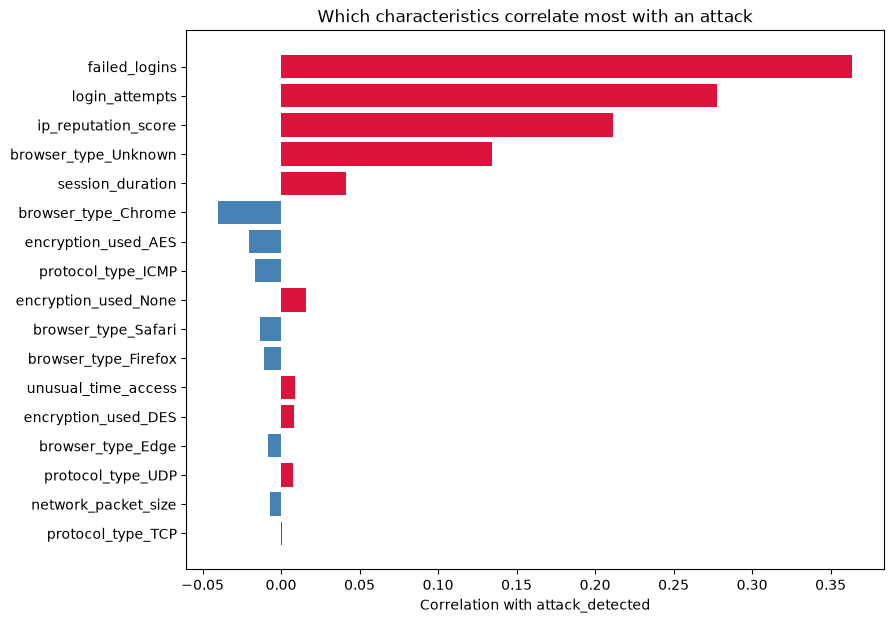

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))
colors = corr.apply(lambda v: 'crimson' if v > 0 else 'steelblue')
plt.barh(corr.index, corr.values, color=colors)
plt.xlabel('Correlation with attack_detected')
plt.title('Which characteristics correlate most with an attack')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Correlation Heatmaps

The full heatmap (all encoded features) and the numeric-only heatmap both confirm the same pattern: `failed_logins`, `login_attempts`, and `ip_reputation_score` are the columns most correlated with `attack_detected`, while packet size and unusual-time access show almost no relationship.

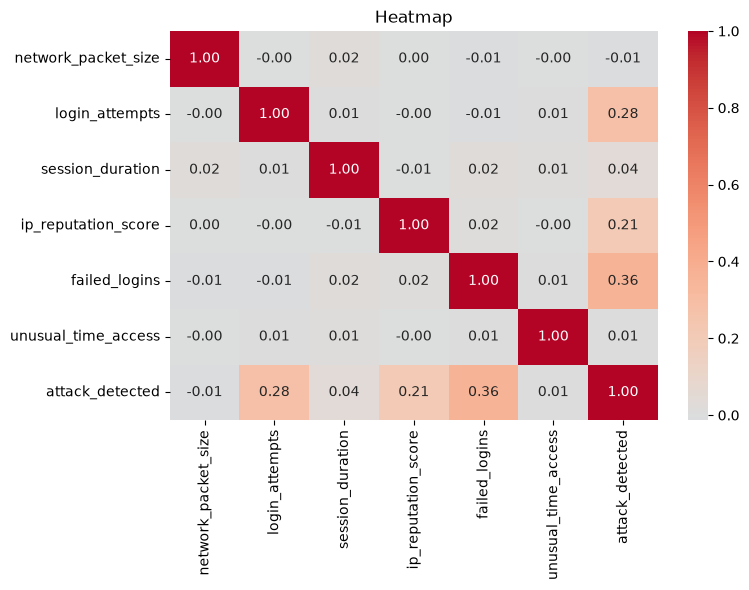

In [7]:
numeric_cols = ['network_packet_size', 'login_attempts', 'session_duration',
                'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'attack_detected']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features Only')
plt.tight_layout()
plt.show()

## 6. Attack Rate by Category

Breaking attack rate down by category shows browser type is the most striking split: sessions with an **`Unknown` browser show a 73.1% attack rate**, versus 42–44% for known browsers. Protocol type and encryption type show only small differences (all in the low-to-mid 40% range).

In [8]:
for col in ['protocol_type', 'encryption_used', 'browser_type']:
    print(f'--- Attack rate by {col} ---')
    print(df.groupby(col)['attack_detected'].mean().round(3).sort_values(ascending=False))
    print()

--- Attack rate by protocol_type ---
protocol_type
UDP     0.454
TCP     0.447
ICMP    0.412
Name: attack_detected, dtype: float64

--- Attack rate by encryption_used ---
encryption_used
None    0.463
DES     0.453
AES     0.437
Name: attack_detected, dtype: float64

--- Attack rate by browser_type ---
browser_type
Unknown    0.731
Edge       0.438
Firefox    0.437
Chrome     0.429
Safari     0.419
Name: attack_detected, dtype: float64



## 7. Failed Logins vs. Login Attempts

Plotting failed logins against login attempts, colored by attack status, visually confirms the correlation results: attacked sessions cluster toward higher values of both.

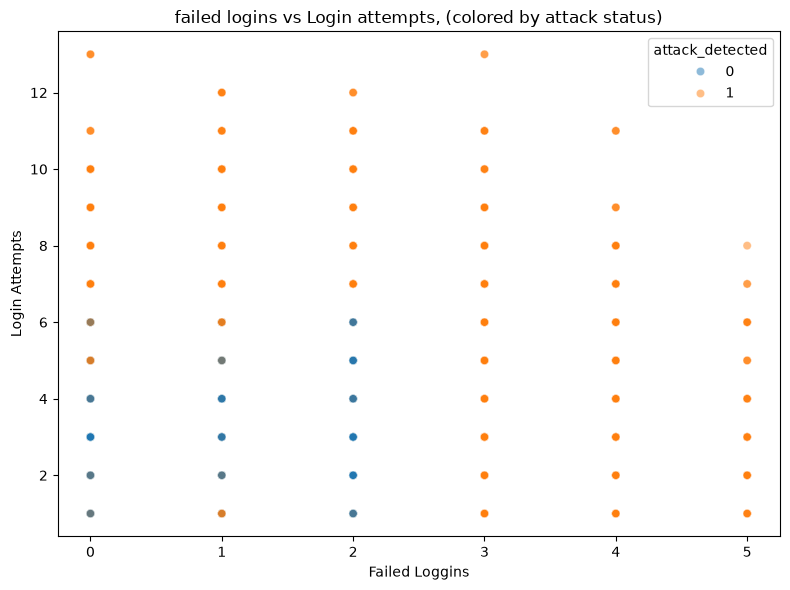

In [9]:
sns.scatterplot(data=df, x='failed_logins', y='login_attempts', hue='attack_detected', alpha=0.5)
plt.title('Failed Logins vs Login Attempts (colored by attack status)')
plt.xlabel('Failed Logins')
plt.ylabel('Login Attempts')
plt.show()

## 8. Summary of Findings

- **Strongest predictors of an attack:** `failed_logins`, `login_attempts`, and `ip_reputation_score` — all positively correlated with `attack_detected`.
- **Attacked sessions on average** have ~64% more failed logins and ~31% more login attempts than normal sessions.
- **Browser type stands out categorically**: sessions with an unidentified (`Unknown`) browser are attacked at a much higher rate (73.1%) than any other browser.
- **Protocol type, encryption type, session duration, packet size, and time-of-access** show little to no meaningful relationship with attack likelihood on their own.
- **Practical takeaway:** login-behavior signals (failed logins, login attempts) and IP reputation are far more useful for attack detection than network/protocol-level metadata in this dataset.
